In [2]:
!pip install matplotlib 

In [2]:
!pip install datasets faker


     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.9 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 60.9/60.9 kB 817.7 kB/s eta 0:00:00
  Using cached pyarrow-21.0.0-cp312-cp312-win_amd64.whl.metadata (3.4 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.6.0-cp312-cp312-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-0.35.3-py3-none-any.whl.metadata (14 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached tzdat


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from datasets import load_dataset, Dataset, DatasetDict
from faker import Faker
import random
import string

o:\REDACTION_SYSTEM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STEP 1: Load PII Dataset and Filter Categories

In [4]:
print("\n[1/4] Loading ai4privacy dataset and filtering categories...")
pii_dataset = load_dataset("ai4privacy/pii-masking-400k", split="train", streaming=True)

# Categories we want: SSN, Credit Card, IP Address, Bank Account, OTP
target_categories = ['ssn', 'credit', 'ip', 'bank', 'otp', 'credit_card', 
                     'credit_card_number', 'creditcard', 'iban', 'swift',
                     'account_number', 'routing_number', 'ipaddress', 
                     'ip_address', 'social_security']

sensitive_pii_examples = []
count = 0
max_examples = 30000  # Take 30k examples

for example in pii_dataset:
    if count >= max_examples:
        break
    
    # Get the source text (contains PII)
    text = example.get('source_text', '')
    
    if text:
        # Check if this example contains our target categories
        # Note: We'll take all examples since the dataset doesn't expose 
        # which specific PII types are in each text easily
        sensitive_pii_examples.append({
            'text': text,
            'label': 1,
            'category': 'pii'
        })
        count += 1
    
    if count % 5000 == 0:
        print(f"  Processed {count} PII examples...")

print(f"✓ Loaded {len(sensitive_pii_examples)} PII examples (SSN, Credit Cards, IP, Bank, OTP)")


[1/4] Loading ai4privacy dataset and filtering categories...
  Processed 5000 PII examples...
  Processed 10000 PII examples...
  Processed 15000 PII examples...
  Processed 20000 PII examples...
  Processed 25000 PII examples...
  Processed 30000 PII examples...
✓ Loaded 30000 PII examples (SSN, Credit Cards, IP, Bank, OTP)


STEP 2: Generate API Key Examples using Faker

In [5]:
fake = Faker()
print("\n[2/4] Generating API key examples using Faker...")

def generate_api_keys_with_faker(num_examples=10000):
    """Generate synthetic API keys and tokens"""
    api_examples = []
    
    # Different API key formats
    def generate_openai_key():
        return f"sk-{''.join(random.choices(string.ascii_letters + string.digits, k=48))}"
    
    def generate_google_key():
        return f"AIza{''.join(random.choices(string.ascii_letters + string.digits + '-_', k=35))}"
    
    def generate_github_token():
        return f"ghp_{''.join(random.choices(string.ascii_letters + string.digits, k=36))}"
    
    def generate_aws_key():
        return f"AKIA{''.join(random.choices(string.ascii_uppercase + string.digits, k=16))}"
    
    def generate_stripe_key():
        return f"sk_live_{''.join(random.choices(string.ascii_letters + string.digits, k=24))}"
    
    def generate_generic_key():
        return ''.join(random.choices(string.ascii_letters + string.digits, k=32))
    
    def generate_jwt_token():
        header = ''.join(random.choices(string.ascii_letters + string.digits, k=16))
        payload = ''.join(random.choices(string.ascii_letters + string.digits, k=16))
        signature = ''.join(random.choices(string.ascii_letters + string.digits, k=16))
        return f"{header}.{payload}.{signature}"
    
    # Templates with context
    templates = [
        "My API key is {key}",
        "Here's the authentication token: {key}",
        "Use this API key: {key}",
        "API_KEY={key}",
        "Authorization: Bearer {key}",
        "The secret key is {key}",
        "export OPENAI_API_KEY={key}",
        "const apiKey = '{key}';",
        "API credentials: {key}",
        "Access token: {key}",
        "Your authentication key: {key}",
        "curl -H 'Authorization: {key}' https://api.example.com",
        "Please use this key to authenticate: {key}",
        "My OpenAI key: {key}",
        "GitHub Personal Access Token: {key}",
        "AWS Access Key ID: {key}",
        "Stripe API Key: {key}",
        "JWT Token: {key}",
        "Application Secret: {key}",
        "Database password is {key} and the API key is in the config",
    ]
    
    key_generators = [
        generate_openai_key,
        generate_google_key,
        generate_github_token,
        generate_aws_key,
        generate_stripe_key,
        generate_generic_key,
        generate_jwt_token,
    ]
    
    for i in range(num_examples):
        template = random.choice(templates)
        key_generator = random.choice(key_generators)
        api_key = key_generator()
        
        text = template.format(key=api_key)
        
        api_examples.append({
            'text': text,
            'label': 1,
            'category': 'api_key'
        })
        
        if (i + 1) % 2000 == 0:
            print(f"  Generated {i + 1} API key examples...")
    
    return api_examples

api_key_examples = generate_api_keys_with_faker(10000)
print(f"✓ Generated {len(api_key_examples)} API key examples")



[2/4] Generating API key examples using Faker...
  Generated 2000 API key examples...
  Generated 4000 API key examples...
  Generated 6000 API key examples...
  Generated 8000 API key examples...
  Generated 10000 API key examples...
✓ Generated 10000 API key examples


STEP 3: Combine All Sensitive Data

In [6]:
print("\n[3/4] Combining sensitive data...")
all_sensitive = sensitive_pii_examples + api_key_examples
random.shuffle(all_sensitive)

print(f"✓ Total sensitive examples: {len(all_sensitive)}")
print(f"  - PII (SSN, Credit Card, IP, Bank, OTP): {len(sensitive_pii_examples)}")
print(f"  - API Keys: {len(api_key_examples)}")


[3/4] Combining sensitive data...
✓ Total sensitive examples: 40000
  - PII (SSN, Credit Card, IP, Bank, OTP): 30000
  - API Keys: 10000


STEP 4: Load Wikipedia (Non-Sensitive Data)

In [7]:
print("\n[4/4] Loading Wikipedia for non-sensitive data...")
wiki_dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split='train', streaming=True)


non_sensitive_examples = []
target_count = len(all_sensitive)  # Match the number of sensitive examples

for i, example in enumerate(wiki_dataset):
    if len(non_sensitive_examples) >= target_count:
        break
    
    text = example['text']
    
    # Filter out very short texts
    if len(text.split()) > 20:
        non_sensitive_examples.append({
            'text': text[:500],  # Truncate to manageable length
            'label': 0,
            'category': 'non_sensitive'
        })
    
    if (i + 1) % 10000 == 0:
        print(f"  Processed {i + 1} Wikipedia articles, collected {len(non_sensitive_examples)}...")

print(f"✓ Loaded {len(non_sensitive_examples)} non-sensitive examples")


[4/4] Loading Wikipedia for non-sensitive data...
  Processed 10000 Wikipedia articles, collected 4133...
  Processed 20000 Wikipedia articles, collected 8171...
  Processed 30000 Wikipedia articles, collected 12269...
  Processed 40000 Wikipedia articles, collected 16695...
  Processed 50000 Wikipedia articles, collected 20776...
  Processed 60000 Wikipedia articles, collected 24858...
  Processed 70000 Wikipedia articles, collected 29098...
  Processed 80000 Wikipedia articles, collected 33077...
  Processed 90000 Wikipedia articles, collected 37141...
✓ Loaded 40000 non-sensitive examples


STEP 5: Merge and Create Final Dataset

In [8]:
print("MERGING DATA AND CREATING FINAL DATASET")
print("="*60)

all_data = all_sensitive + non_sensitive_examples
random.shuffle(all_data)

print(f"\nTotal examples: {len(all_data)}")

# Split into train/validation/test
train_size = int(0.8 * len(all_data))
val_size = int(0.1 * len(all_data))

train_data = all_data[:train_size]
val_data = all_data[train_size:train_size+val_size]
test_data = all_data[train_size+val_size:]

# Create HuggingFace Dataset
final_dataset = DatasetDict({
    'train': Dataset.from_list(train_data),
    'validation': Dataset.from_list(val_data),
    'test': Dataset.from_list(test_data)
})

MERGING DATA AND CREATING FINAL DATASET

Total examples: 80000


In [11]:
print("FINAL DATASET STATISTICS")
print(final_dataset)

import pandas as pd
train_df = pd.DataFrame(final_dataset['train'])
print(f"\nLabel Distribution:")
print(train_df['label'].value_counts())
print(f"\n  0 = Non-Sensitive (Wikipedia)")
print(f"  1 = Sensitive (PII + API Keys)")

print(f"\nCategory Distribution:")
train_df['category'].value_counts()

FINAL DATASET STATISTICS
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'category'],
        num_rows: 64000
    })
    validation: Dataset({
        features: ['text', 'label', 'category'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['text', 'label', 'category'],
        num_rows: 8000
    })
})

Label Distribution:
label
0    32135
1    31865
Name: count, dtype: int64

  0 = Non-Sensitive (Wikipedia)
  1 = Sensitive (PII + API Keys)

Category Distribution:


category
non_sensitive    32135
pii              23885
api_key           7980
Name: count, dtype: int64

In [9]:
output_path = "./pii_dataset"
final_dataset.save_to_disk(output_path)
print(f"\n✓ Dataset saved to '{output_path}'")

Saving the dataset (1/1 shards): 100%|██████████| 8000/8000 [00:00<00:00, 1332529.76 examples/s]


✓ Dataset saved to './pii_dataset'


C:\Users\gnana\AppData\Local\Temp\ipykernel_24044\2463564697.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


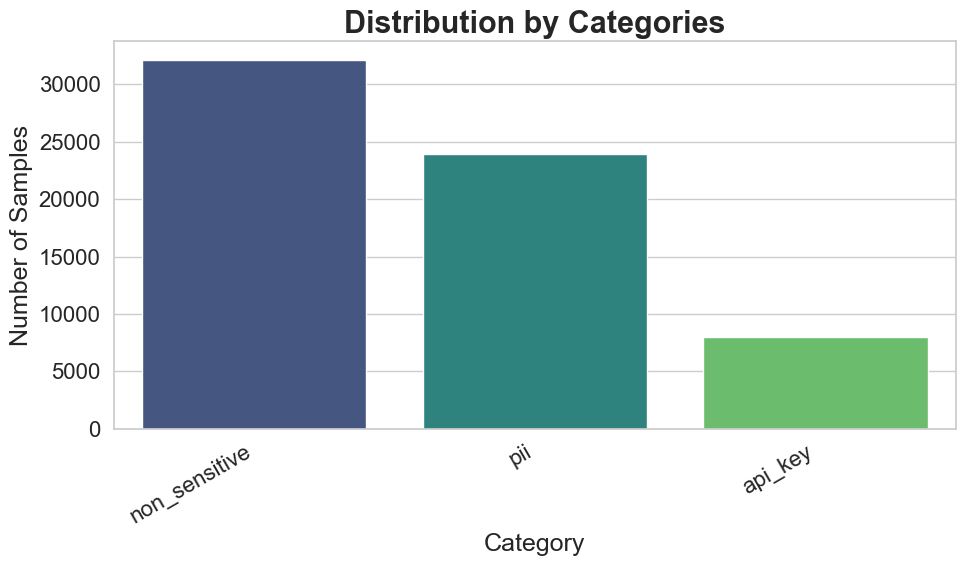

C:\Users\gnana\AppData\Local\Temp\ipykernel_24044\2463564697.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette=['#66b3ff', '#ff9999'])


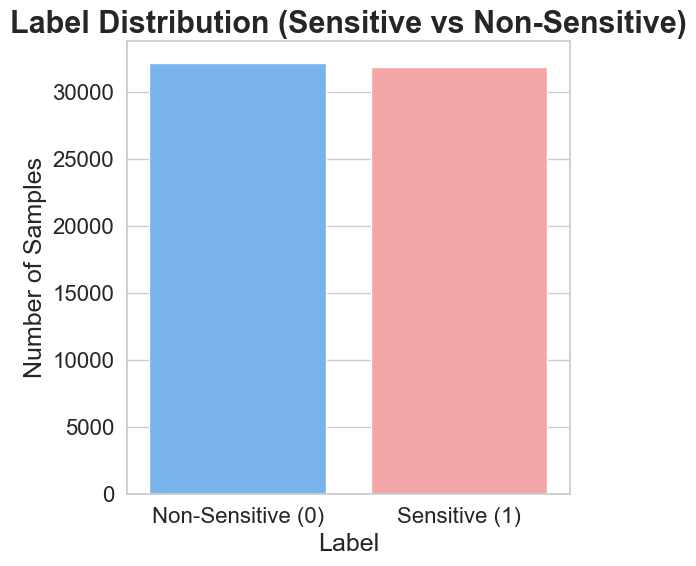

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use clean style and bigger font sizes
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 18,        # Base font size
    'axes.titlesize': 22,   # Title font
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})

# --- Figure 1: Category Distribution ---
category_counts = train_df['category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title("Distribution by Categories", weight='bold')
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# --- Figure 2: Label Distribution ---
label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette=['#66b3ff', '#ff9999'])
plt.title("Label Distribution (Sensitive vs Non-Sensitive)", weight='bold')
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ['Non-Sensitive (0)', 'Sensitive (1)'])
plt.tight_layout()
plt.show()


C:\Users\gnana\AppData\Local\Temp\ipykernel_24044\3091815891.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


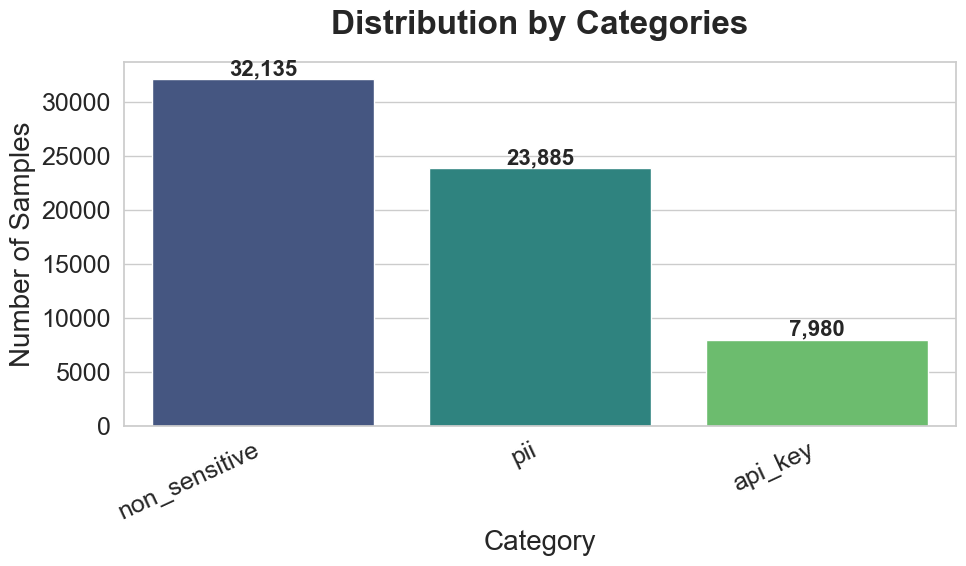

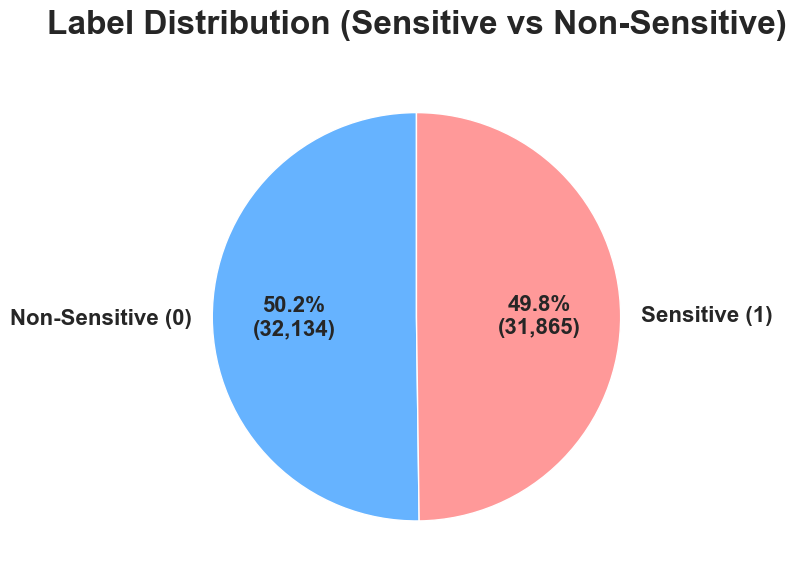

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean presentation style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# ---------------------------
# FIG 1 – Distribution by Categories (Bar Chart)
# ---------------------------
category_counts = train_df['category'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette='viridis'
)
plt.title("Distribution by Categories", weight='bold', pad=20)
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=25, ha='right')

# Annotate values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=16, weight='bold'
    )

plt.tight_layout()
plt.show()

# ---------------------------
# FIG 2 – Label Distribution (Pie Chart)
# ---------------------------
label_counts = train_df['label'].value_counts().sort_index()
labels = ['Non-Sensitive (0)', 'Sensitive (1)']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(
    label_counts.values,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(label_counts) / 100):,})',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 16, 'weight': 'bold'}
)
plt.title("Label Distribution (Sensitive vs Non-Sensitive)", weight='bold', pad=20)
plt.tight_layout()
plt.show()


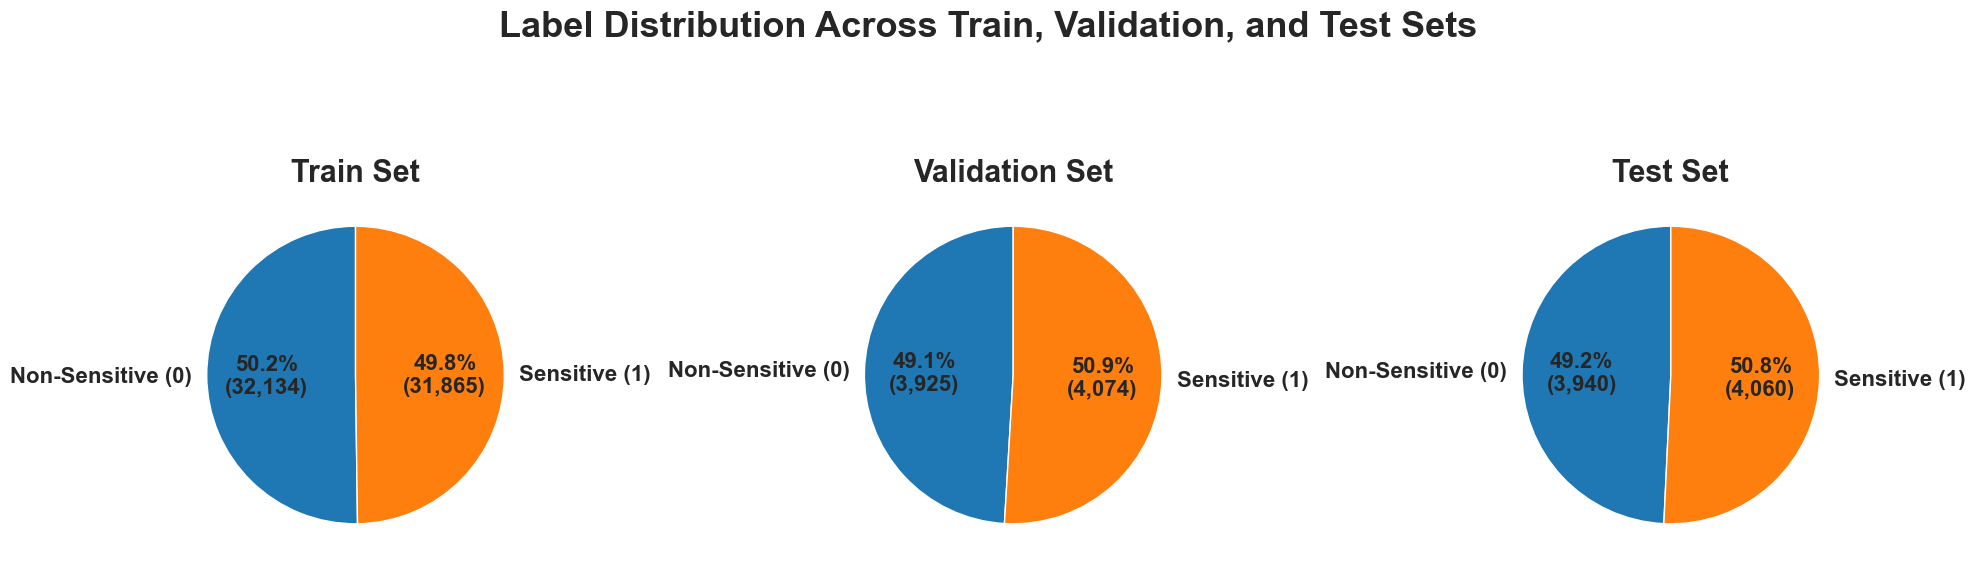

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set bright presentation style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# ---------------------------
# Count labels in each split
# ---------------------------
train_counts = final_dataset['train']['label']
val_counts = final_dataset['validation']['label']
test_counts = final_dataset['test']['label']

splits = {
    'Train': [train_counts.count(0), train_counts.count(1)],
    'Validation': [val_counts.count(0), val_counts.count(1)],
    'Test': [test_counts.count(0), test_counts.count(1)]
}

colors = ['#1f77b4', '#ff7f0e']  # bright blue & orange
labels = ['Non-Sensitive (0)', 'Sensitive (1)']

# ---------------------------
# Create 3 pie charts side by side
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (split, counts) in zip(axes, splits.items()):
    total = sum(counts)
    ax.pie(
        counts,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%\n({int(p*total/100):,})',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 16, 'weight': 'bold'}
    )
    ax.set_title(f"{split} Set", fontsize=22, weight='bold')

plt.suptitle("Label Distribution Across Train, Validation, and Test Sets", fontsize=26, weight='bold', y=0.98)
plt.tight_layout()
plt.show()
